## It doesn't matter what order you put the melt in 
Applying circular_meltx0.1 to DEM, then circular_meltx0.1 to dem+fwt gives the same answer as applying circulr_meltx0.2 to dem.

## It also doesn't matter if you put the melt in as a modification to the DEM or as new melt 
Applying circular_meltx0.2 to dem and applying fwt+(circular_meltx0.1) to dem gives the same answer)

In [1]:
import sys
sys.path.insert(0, "/Users/jkingslake/Documents/science/meltwater_routing/fsm_pywrapper/fillspillmerge")

from fillspillmerge import fill_spill_merge
import pdemtools as pdt
import rioxarray
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np


In [2]:
dem = rioxarray.open_rasterio('Nivlisen_32m_REMA.tif').squeeze()
coarsen_factor = 3
dem = dem[::coarsen_factor, ::coarsen_factor]

In [3]:
center_x = dem.x.mean().values
center_y = dem.y.mean().values

region_size = 5000
circular_mask = (np.abs(dem.x - center_x)**2 + (np.abs(dem.y - center_y)**2) < region_size**2).transpose(*dem.dims)

circular_melt = xr.where(circular_mask, 1, 0.0)

In [4]:
def plot_hist(da):
    da.where(da>0).plot.hist(bins = np.linspace(0, 1.5, 10));
    plt.title(f"mean = {da.where(da>0).mean().values}")

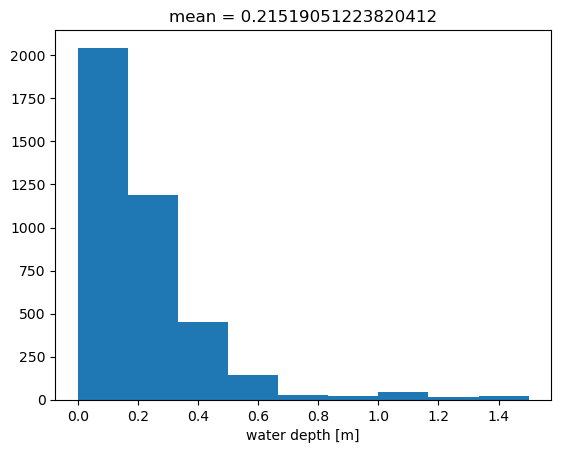

In [5]:
fwt = fill_spill_merge(
    topography=dem,
    wtd = circular_melt*0.1,    
    ocean_level=0.0,
)
plot_hist(fwt)


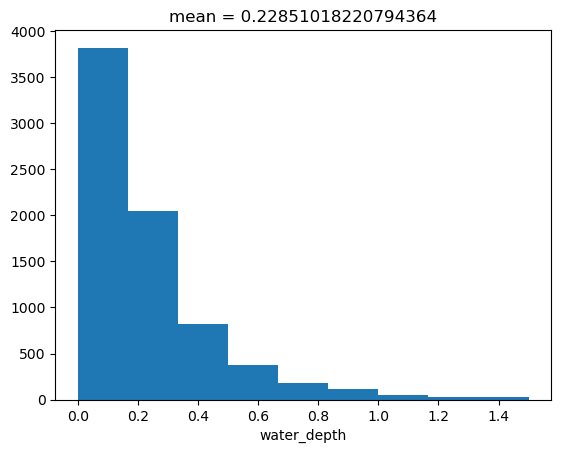

In [6]:
out_slow = fill_spill_merge(
    topography=(dem+fwt),
    wtd = circular_melt*0.1,    
    ocean_level=0.0,
)

fwt_new = out_slow + fwt
plot_hist(fwt_new)


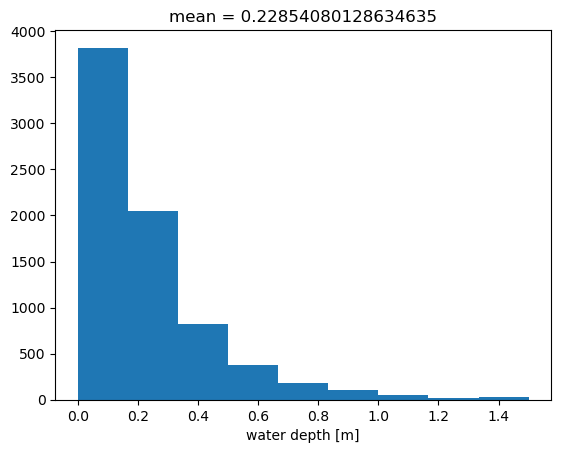

In [7]:
fwt_new_2 = fill_spill_merge(
    topography=dem,
    wtd = circular_melt*0.2,    
    ocean_level=0.0,
)
plot_hist(fwt_new_2)

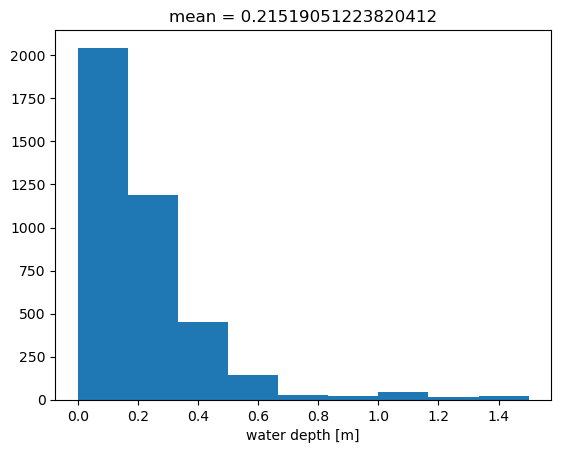

In [8]:
fwt_new_3 = fill_spill_merge(
    topography=dem,
    wtd = fwt,    
    ocean_level=0.0,
)
plot_hist(fwt_new_3)

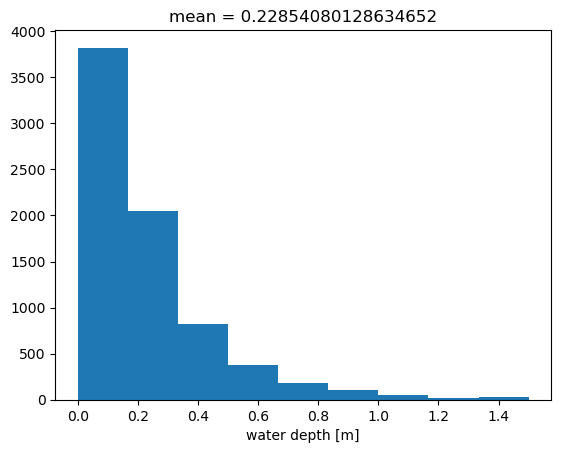

In [9]:
fwt_new_4 = fill_spill_merge(
    topography=dem,
    wtd = fwt+(circular_melt*0.1),    
    ocean_level=0.0,
)
plot_hist(fwt_new_4)